In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import stats

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer

In [ ]:
df = pd.read_csv('/content/concrete_data.csv')
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [ ]:
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


In [ ]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [ ]:
X = df.iloc[:,0:-1]
Y = df.iloc[:,-1]

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.2,random_state=0)

# Applying LR without transformation

In [ ]:
lr = LinearRegression()
lr.fit(X_train, Y_train)

Y_pred = lr.predict(X_test)

r2_score(Y_test, Y_pred)

0.5927690945236268

In [ ]:
# Cross check with Cross Validation

lr = LinearRegression()
np.mean(cross_val_score(lr,X,Y,scoring='r2'))

np.float64(0.46099404916628606)

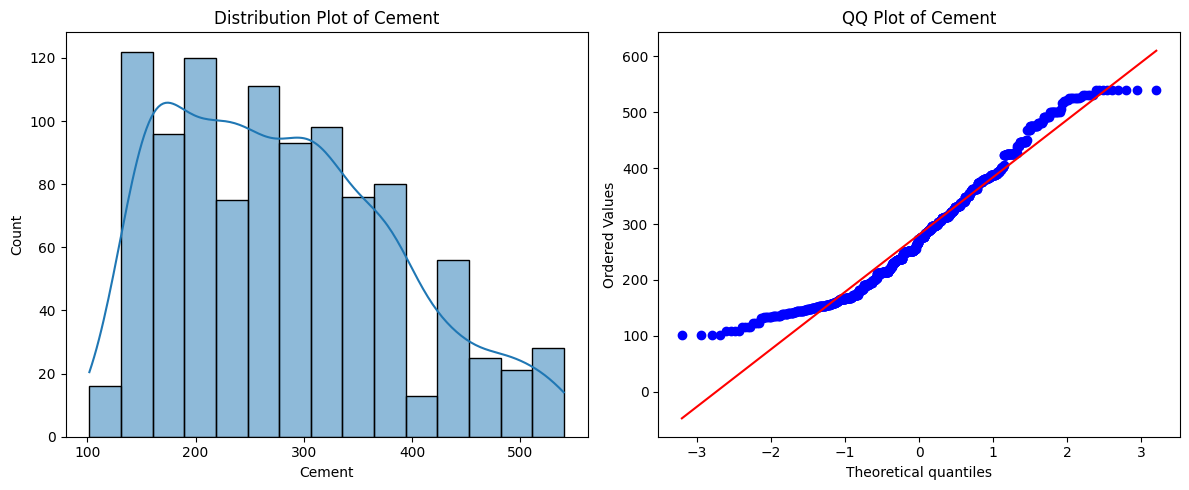

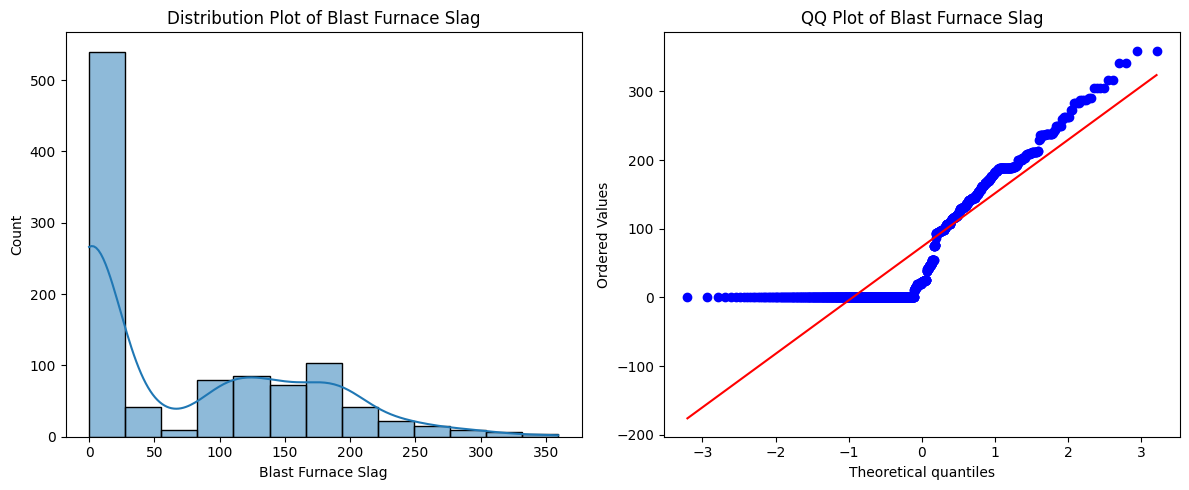

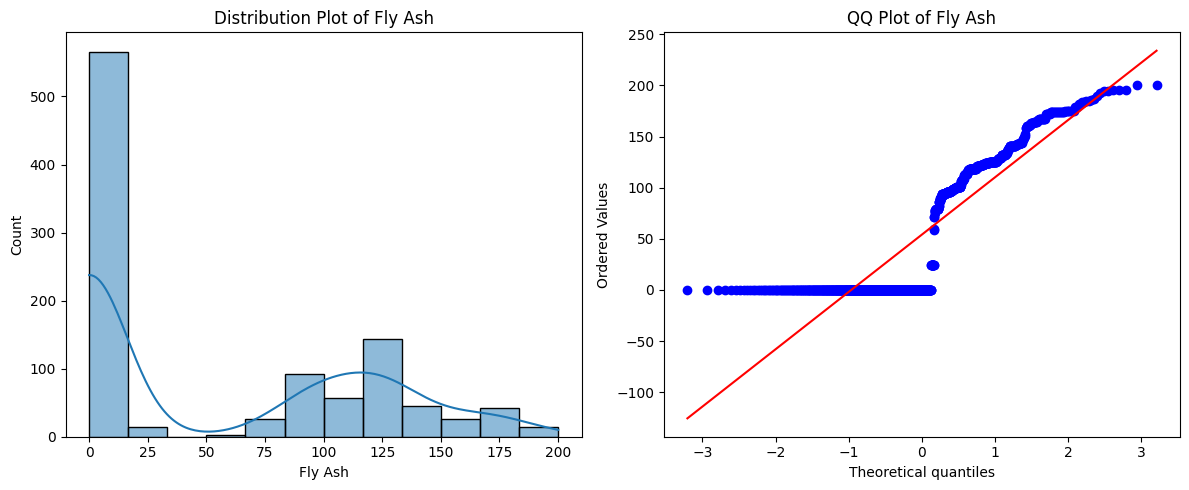

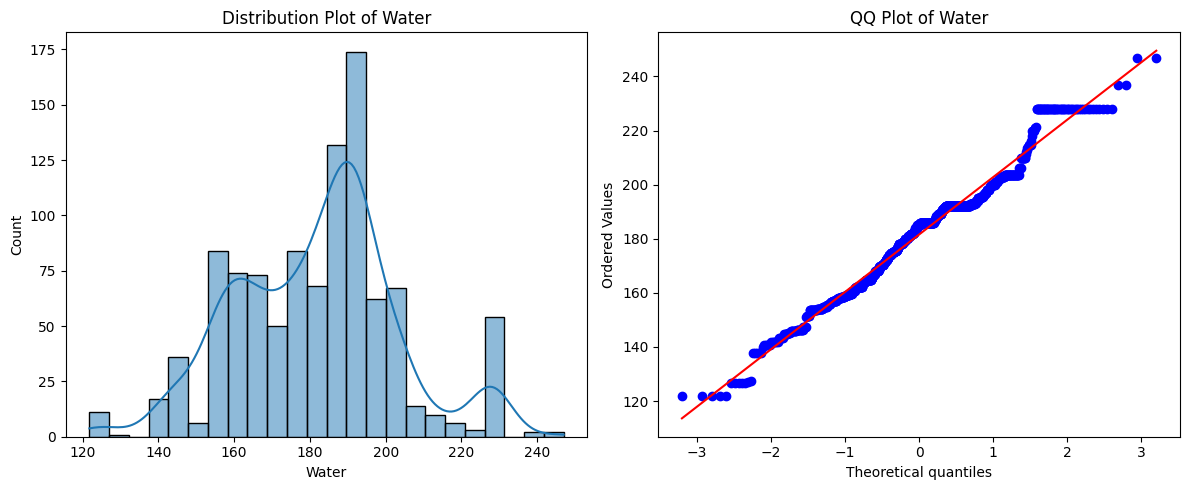

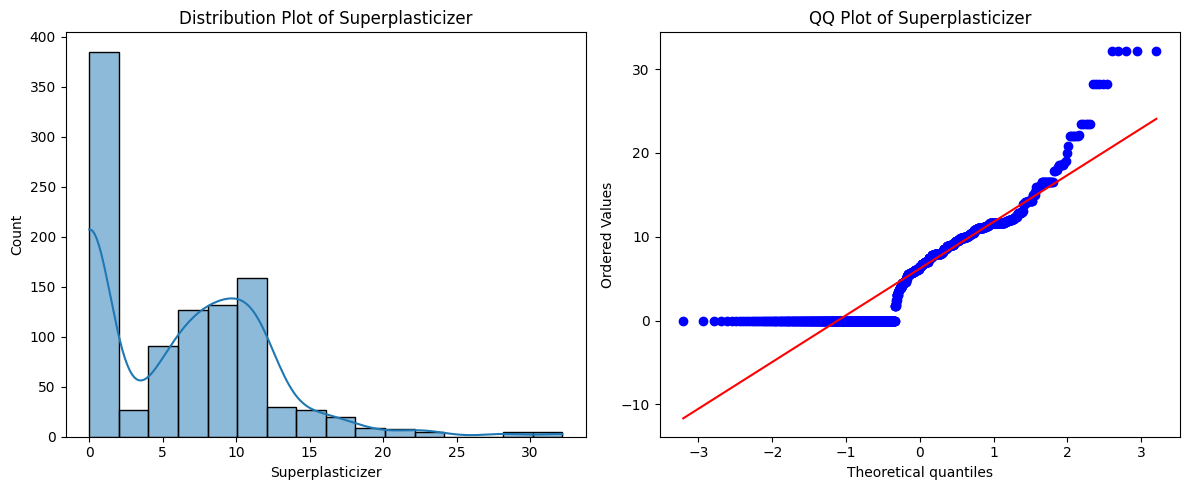

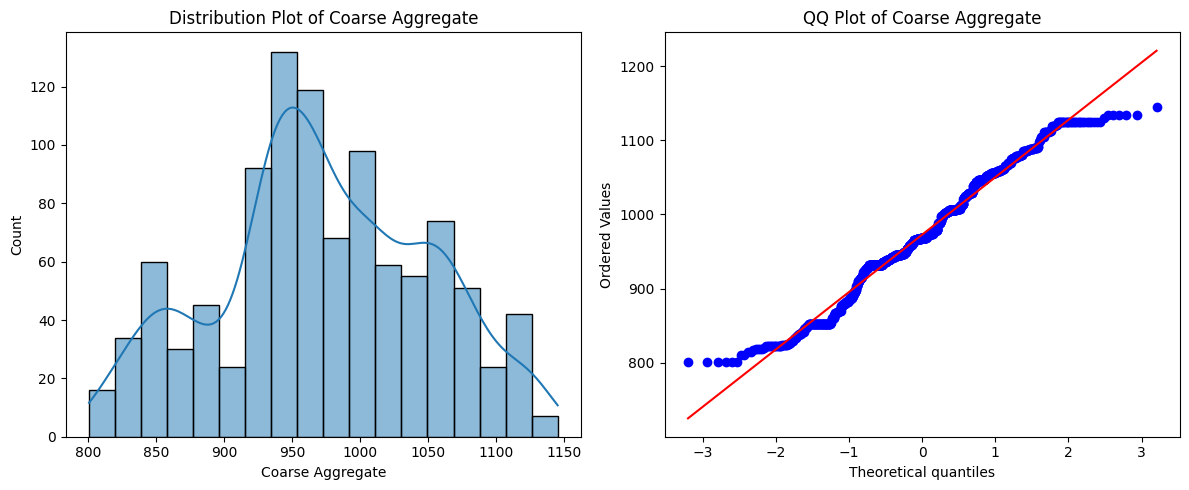

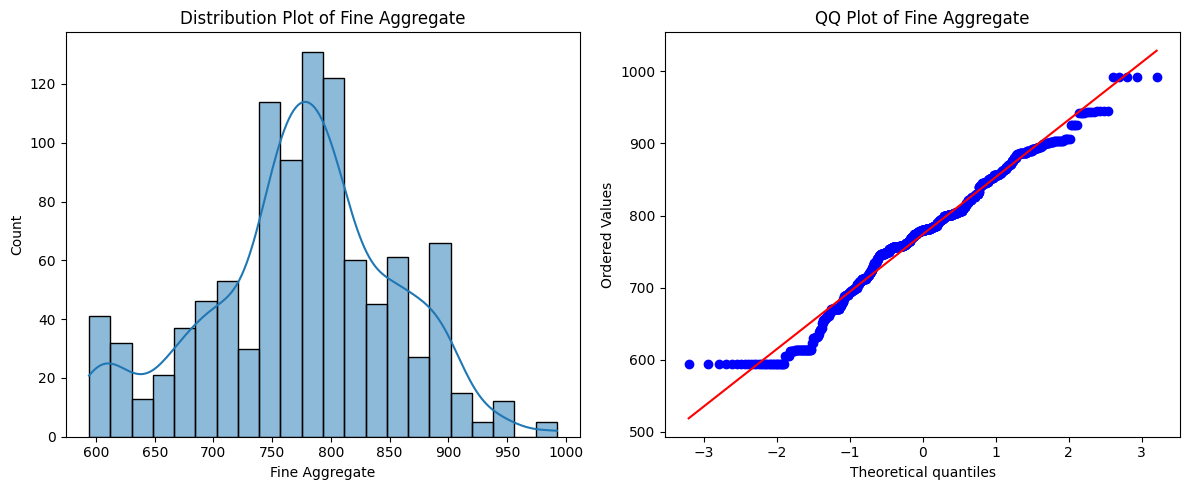

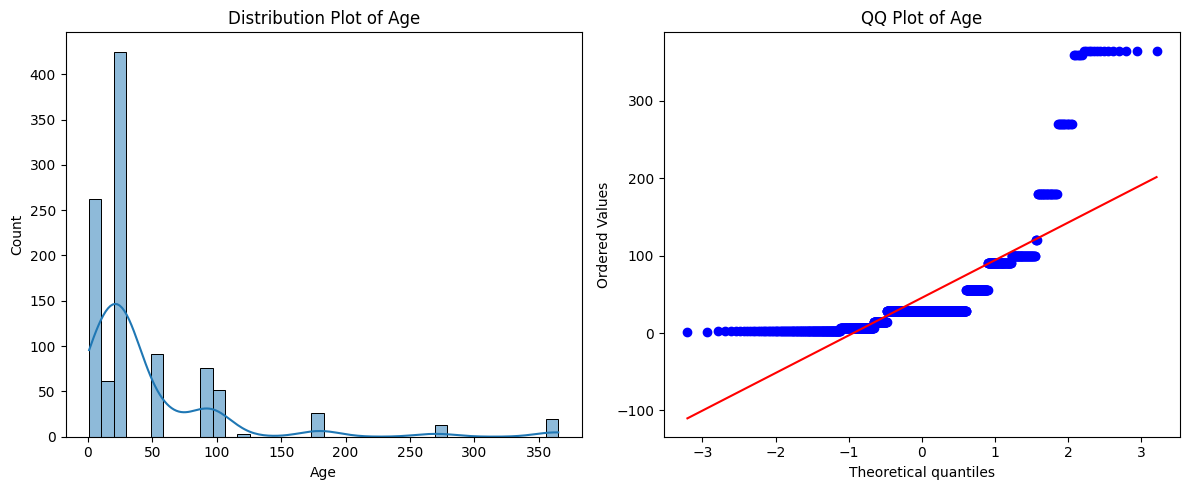

In [ ]:
for col in X.columns:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(X[col], kde=True)
    plt.title(f'Distribution Plot of {col}')

    plt.subplot(1, 2, 2)
    st.probplot(X[col], dist="norm", plot=plt)
    plt.title(f'QQ Plot of {col}')

    plt.tight_layout()
    plt.show()

In [ ]:
# Applying Box-Cox transformation

transformer = PowerTransformer(method='box-cox')

X_train_transformed = transformer.fit_transform(X_train+0.0000001) # to handel the 0 values
X_test_transformed = transformer.transform(X_test+0.0000001)

# to display the lambdas calculated
pd.DataFrame({'cols': X_train.columns, 'box-cox-lambdas':transformer.lambdas_})

,cols,box-cox-lambdas
0,Cement,0.371386
1,Blast Furnace Slag,0.023653
2,Fly Ash,-0.060006
3,Water,1.139535
4,Superplasticizer,0.101811
5,Coarse Aggregate,1.461743
6,Fine Aggregate,1.932956
7,Age,0.040025


NOTE : Box-Cox doesn't handel 0 or -ve values

# Applying LR with Box-Cox transformation

In [ ]:
lr = LinearRegression()
lr.fit(X_train_transformed, Y_train)

Y_pred = lr.predict(X_test_transformed)

r2_score(Y_test, Y_pred)

0.7826381132722486

In [ ]:
# Cross check with Cross Validation

X_transformed = transformer.fit_transform(X+0.0000001)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_transformed,Y,scoring='r2'))

np.float64(0.6658537935432477)

Notice the increase

In [ ]:
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=X_train.columns)
X_train_transformed_df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,0.933050,-1.089309,-0.813181,2.277297,-1.359516,-0.487561,-1.345722,2.116000
1,0.131971,0.980132,-0.813181,-1.614305,0.781128,0.449967,0.249933,-0.999345
2,1.273675,0.902335,-0.813181,-1.215386,0.882638,-1.480988,1.381504,0.718278
3,0.794550,0.972619,-0.813181,-0.693861,0.790158,-0.325911,-0.352772,0.718278
4,0.765376,0.697672,1.236779,-1.192622,0.774164,-0.360362,0.215042,-0.999345


# Comparing before and after transformation

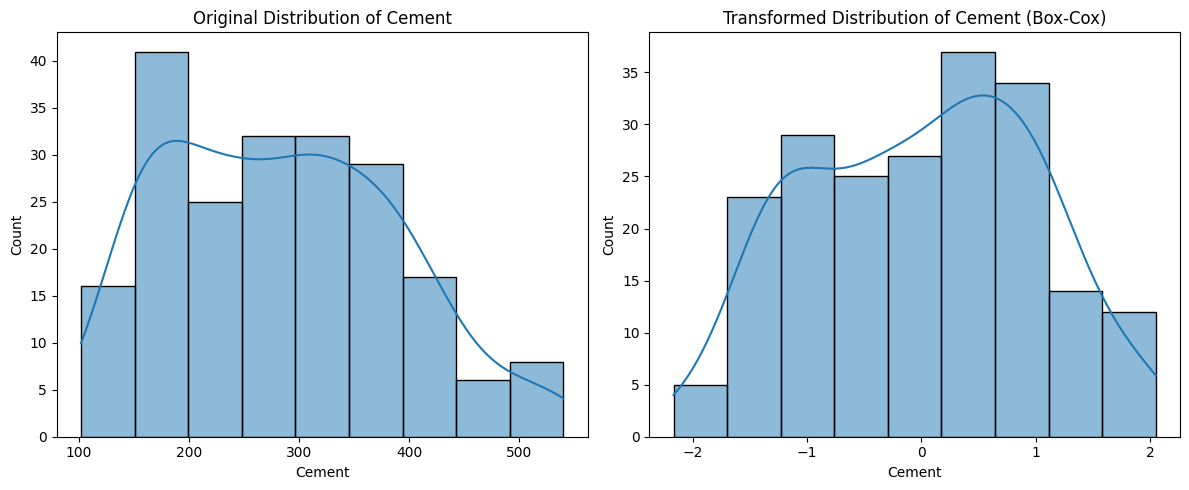

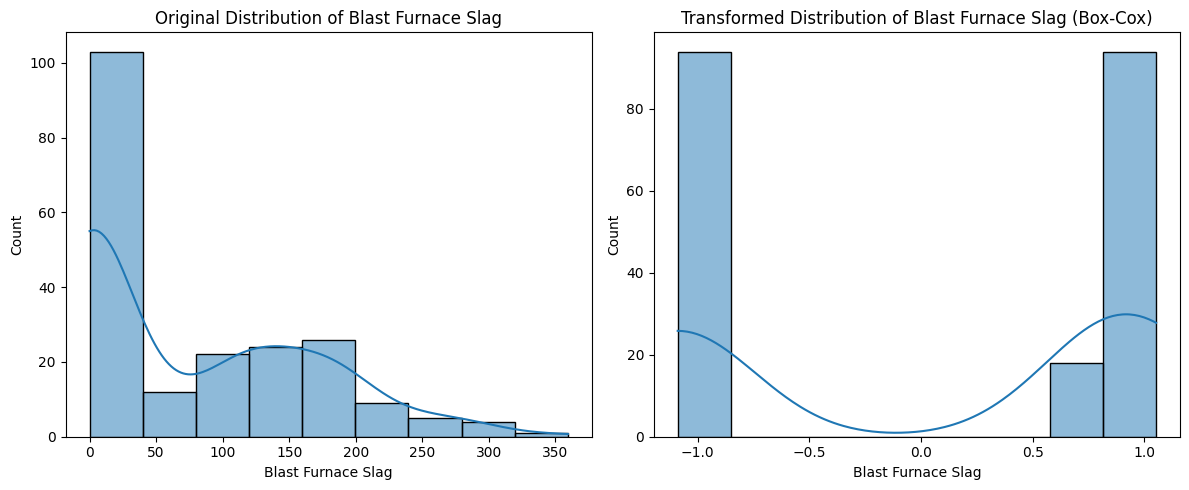

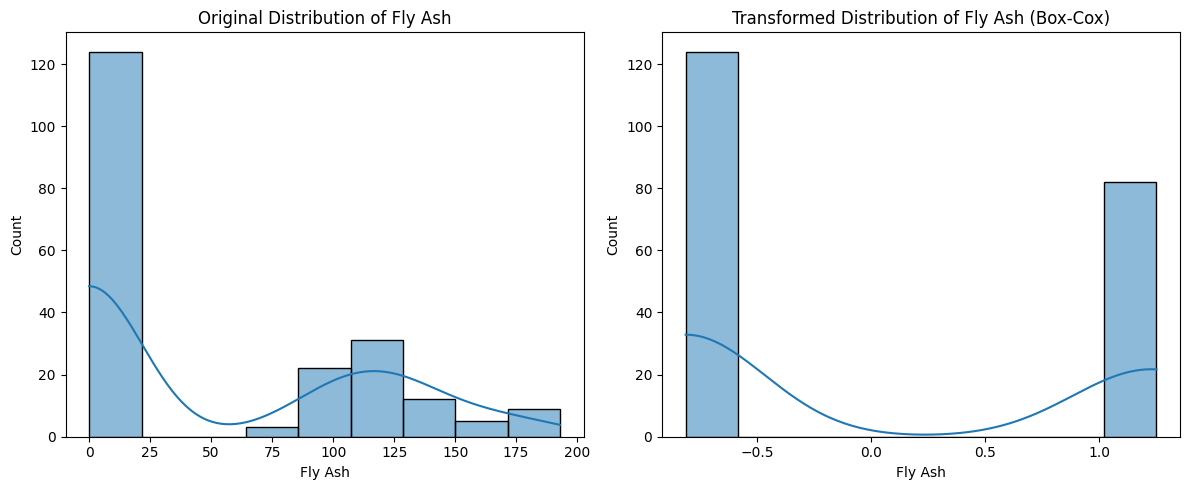

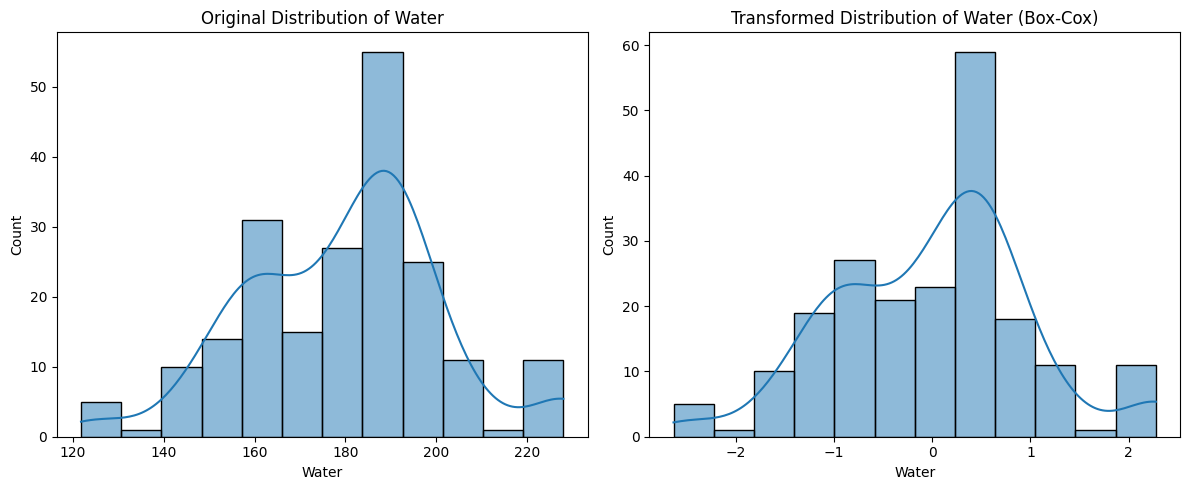

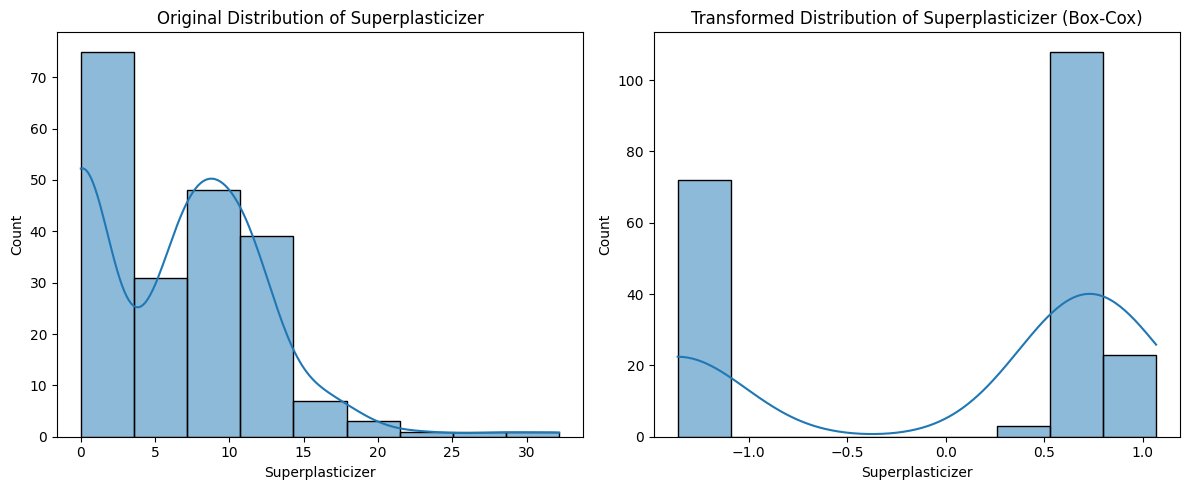

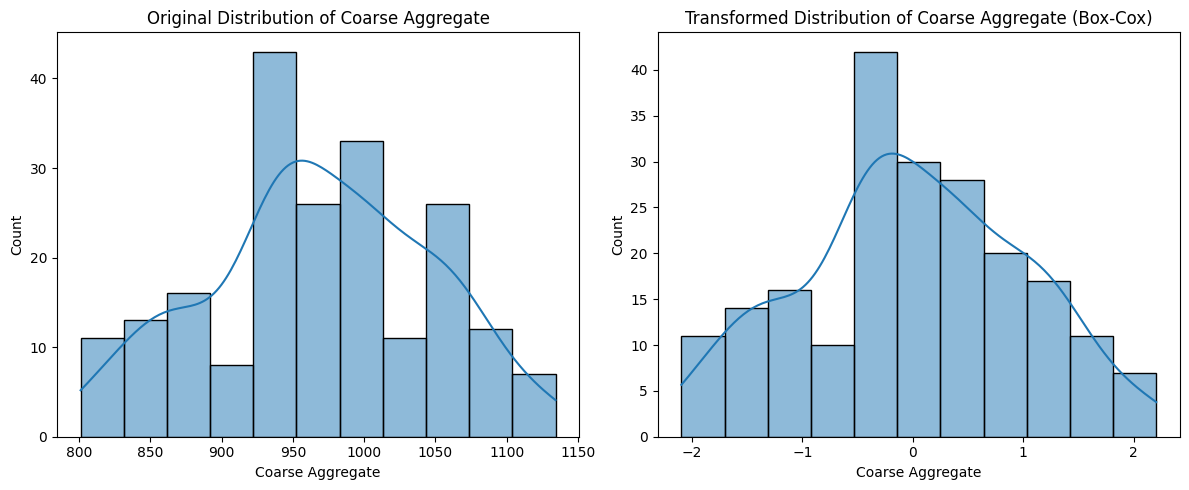

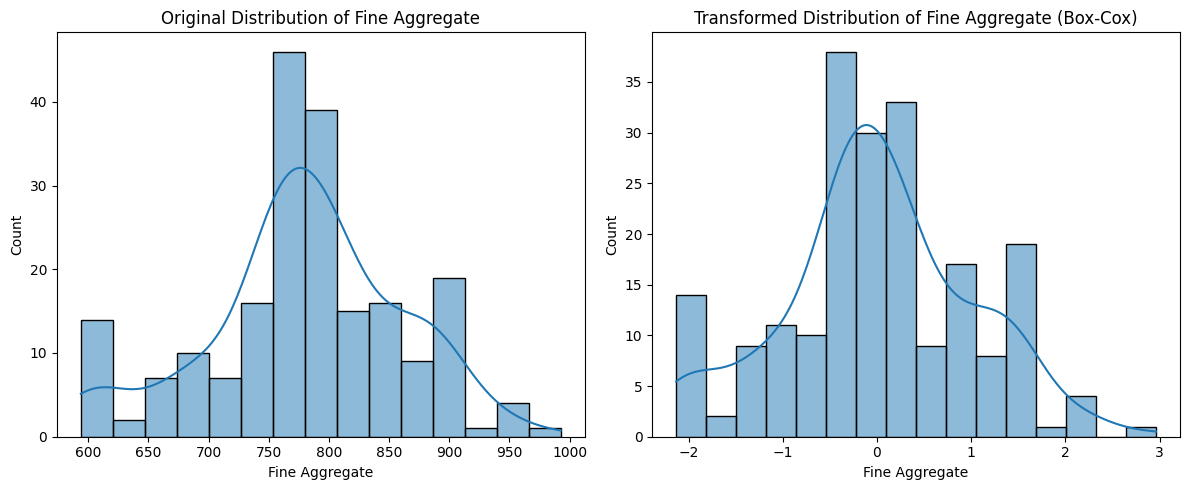

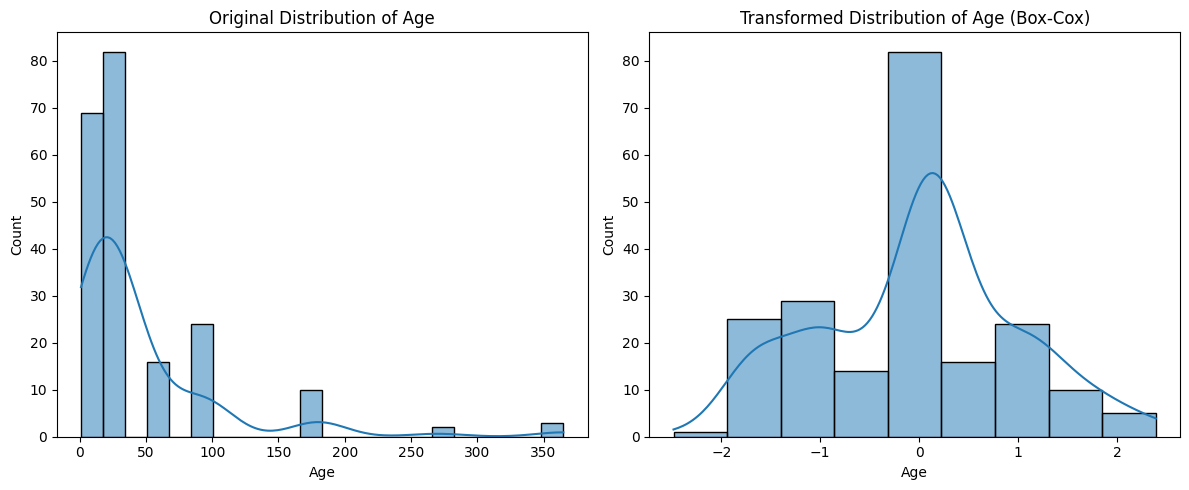

In [ ]:
for col in X_train.columns:
    plt.figure(figsize=(12, 5))

    # Plot original distribution
    plt.subplot(1, 2, 1)
    sns.histplot(X_train[col], kde=True)
    plt.title(f'Original Distribution of {col}')

    # Plot transformed distribution
    plt.subplot(1, 2, 2)
    sns.histplot(X_train_transformed_df[col], kde=True)
    plt.title(f'Transformed Distribution of {col} (Box-Cox)')

    plt.tight_layout()
    plt.show()

# Applying Yeo-Johnson Transformation

In [ ]:
transformer2 = PowerTransformer()

X_train_transformed = transformer2.fit_transform(X_train)
X_test_transformed = transformer2.transform(X_test)

In [ ]:
pd.DataFrame({'cols': X_train.columns, 'box-cox-lambdas':transformer.lambdas_, 'Yeo-Johnson-lambdas':transformer2.lambdas_})

,cols,box-cox-lambdas,Yeo-Johnson-lambdas
0,Cement,0.172271,0.118047
1,Blast Furnace Slag,0.022924,0.013452
2,Fly Ash,-0.028797,-0.106471
3,Water,0.809568,0.705308
4,Superplasticizer,0.087911,0.243166
5,Coarse Aggregate,1.129167,1.047205
6,Fine Aggregate,1.829625,1.808668
7,Age,0.048975,0.004891


In [ ]:
lr = LinearRegression()
lr.fit(X_train_transformed, Y_train)

Y_pred = lr.predict(X_test_transformed)

r2_score(Y_test, Y_pred)

0.7898989123930922

In [ ]:
# Cross check with Cross Validation

X_transformed = transformer2.fit_transform(X)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_transformed,Y,scoring='r2'))

np.float64(0.6834625141500866)

# Box-Cox Vs Yeo-Johnson

In [ ]:
X_boxcox_transformed_df = pd.DataFrame(transformer.transform(X+0.0000001), columns=X.columns)
X_yeojohnson_transformed_df = pd.DataFrame(transformer2.transform(X), columns=X.columns)

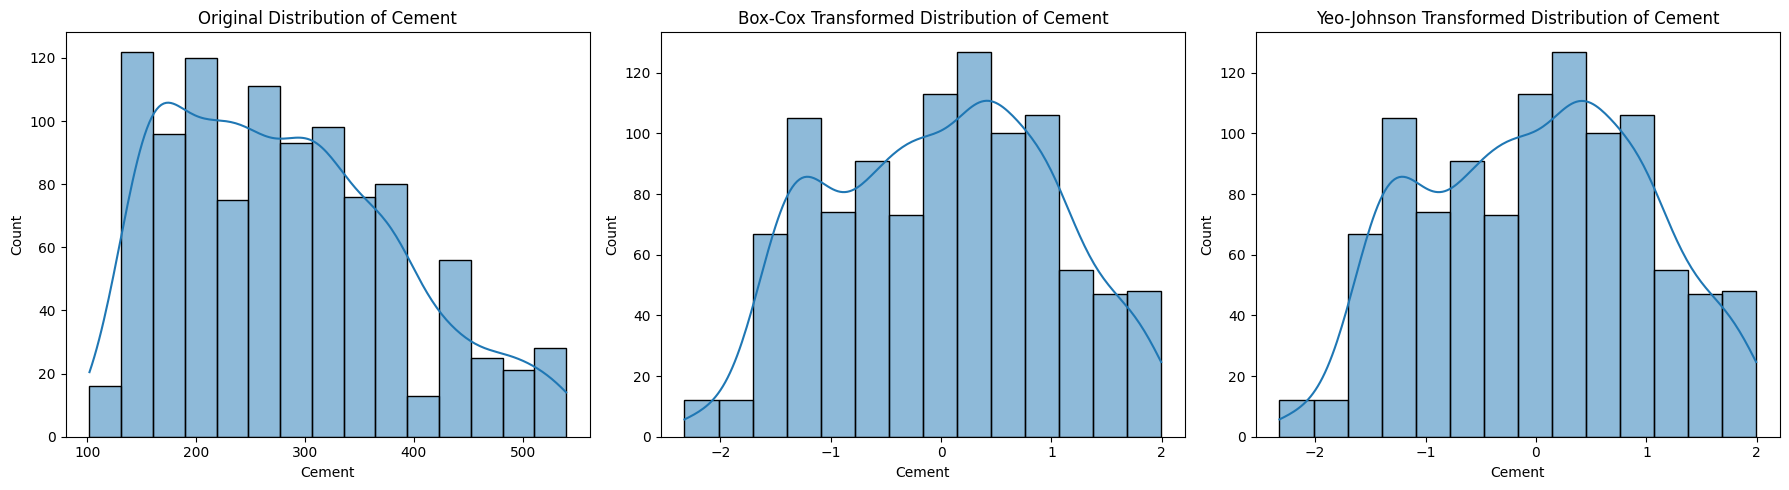

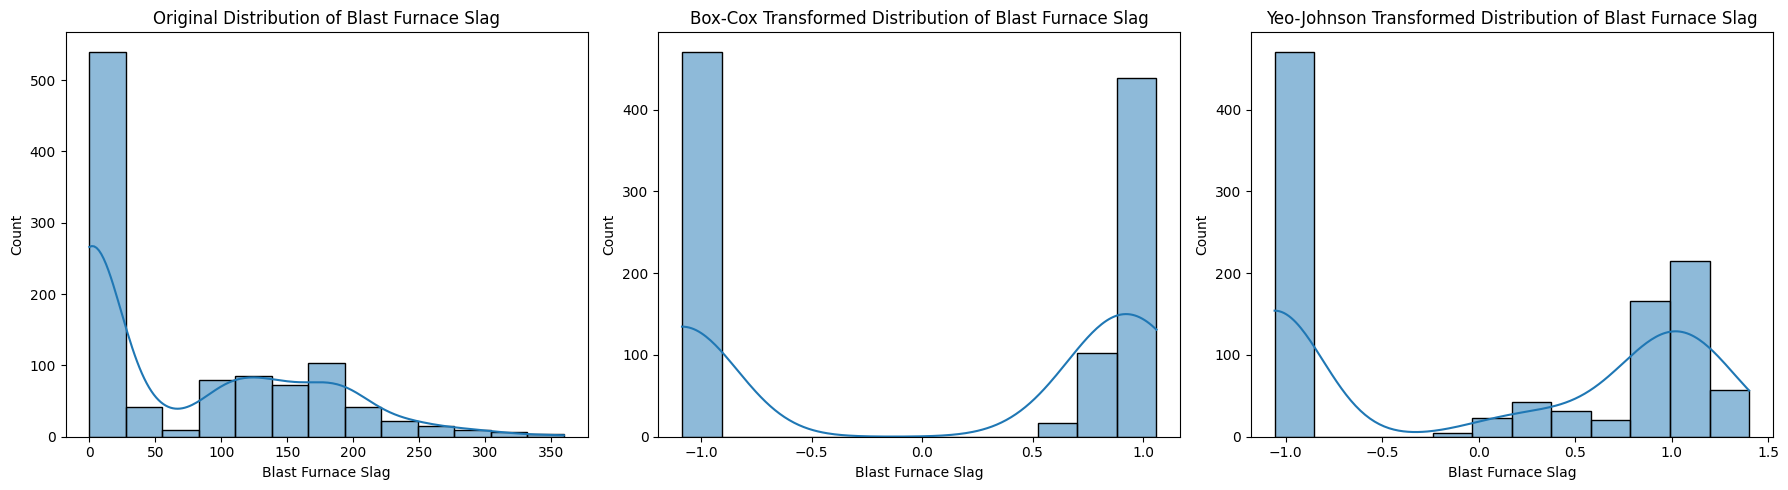

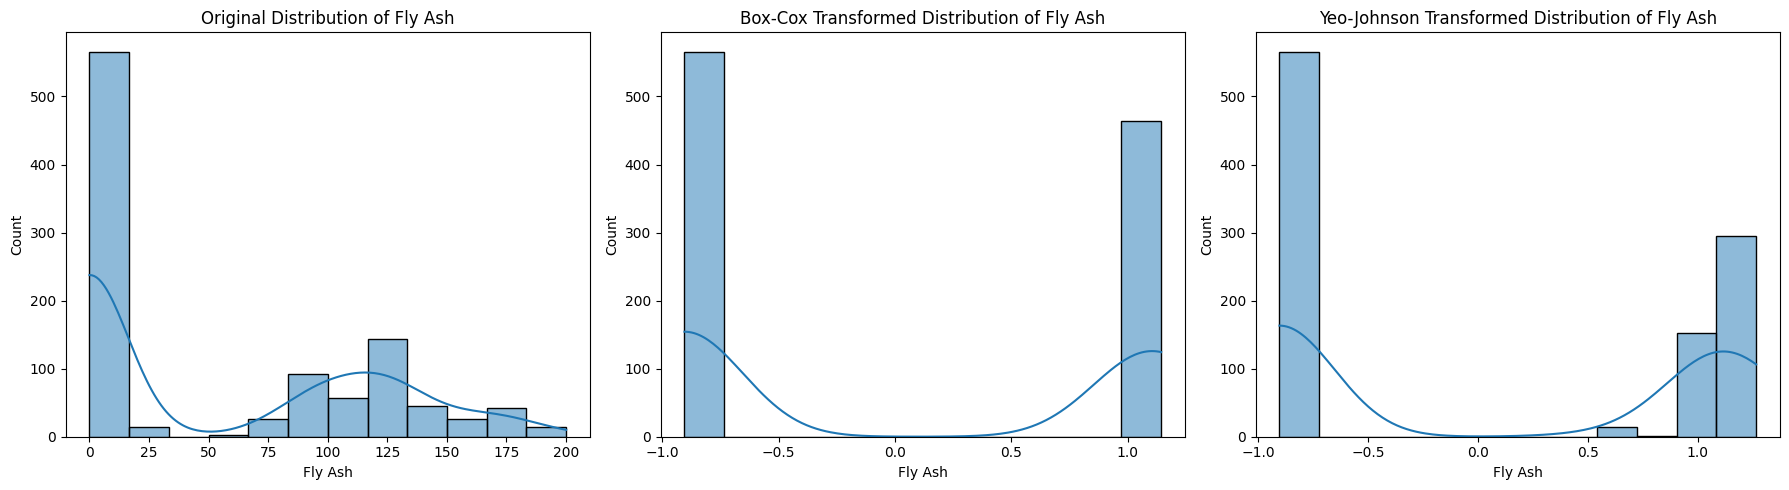

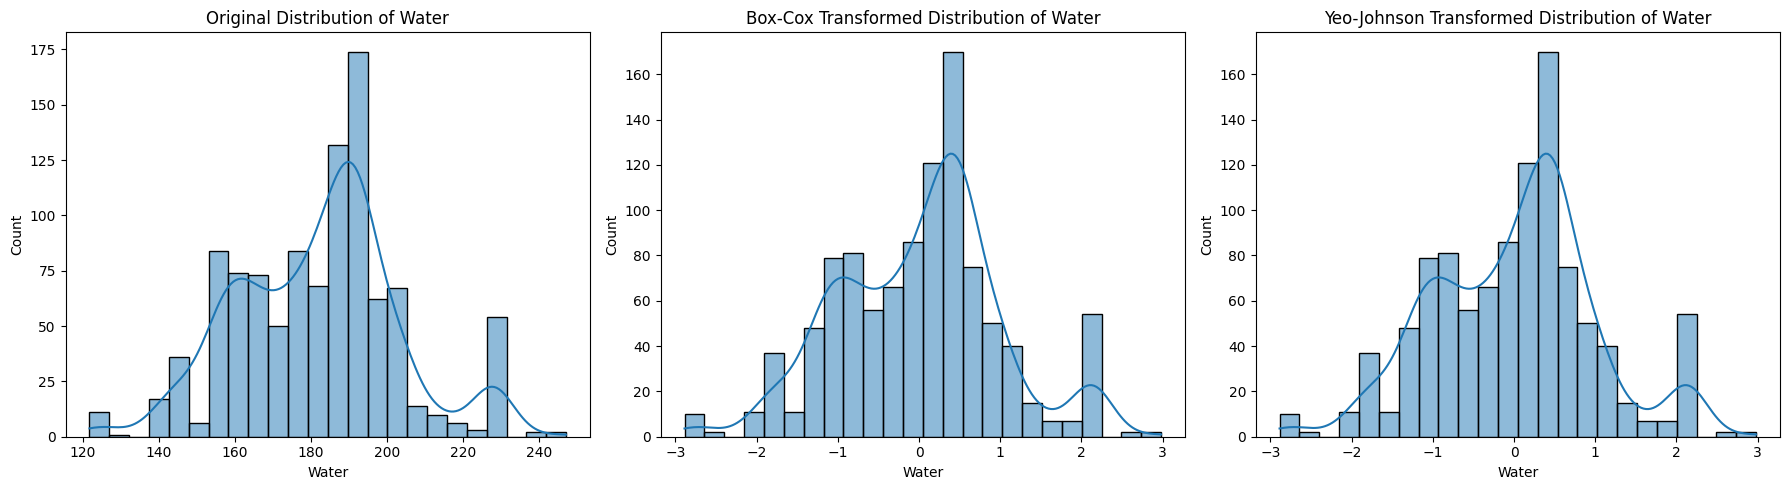

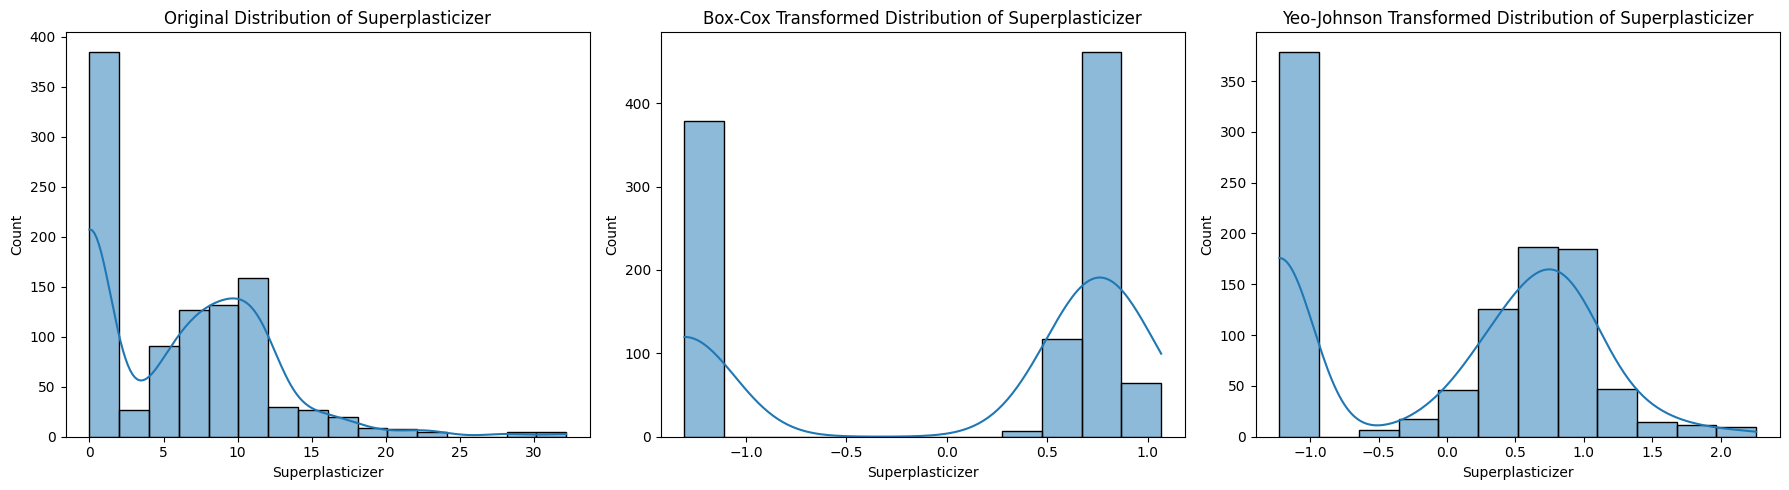

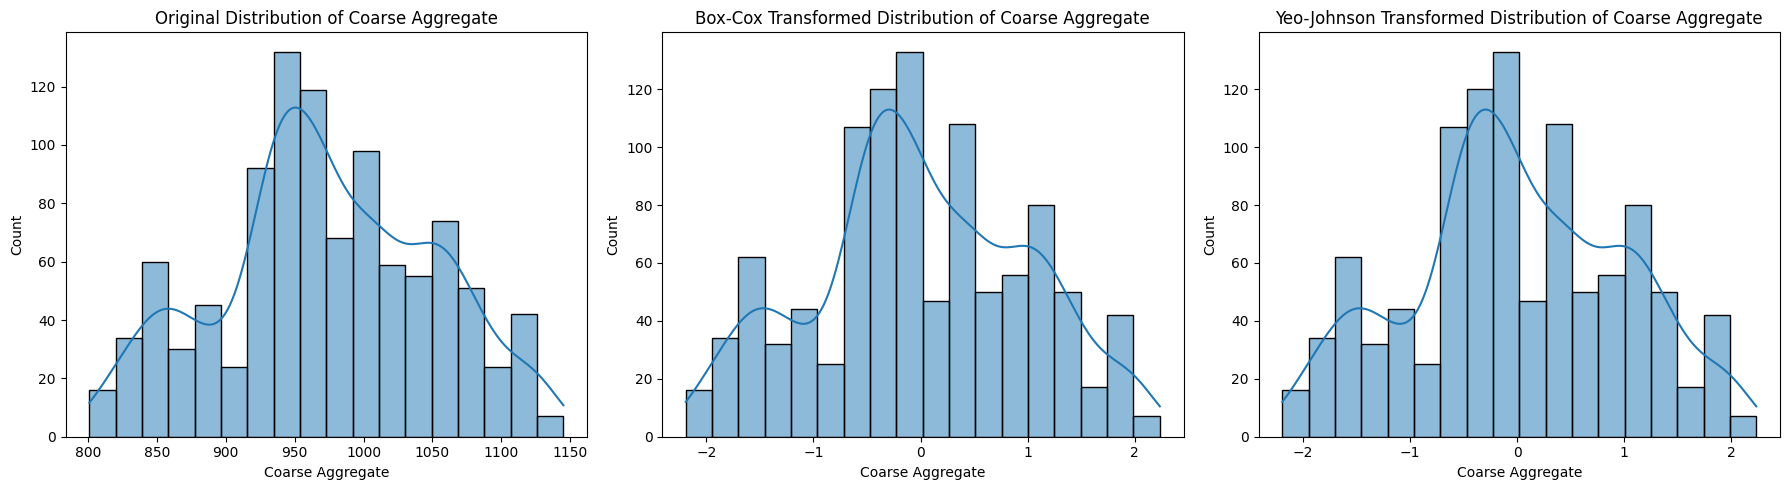

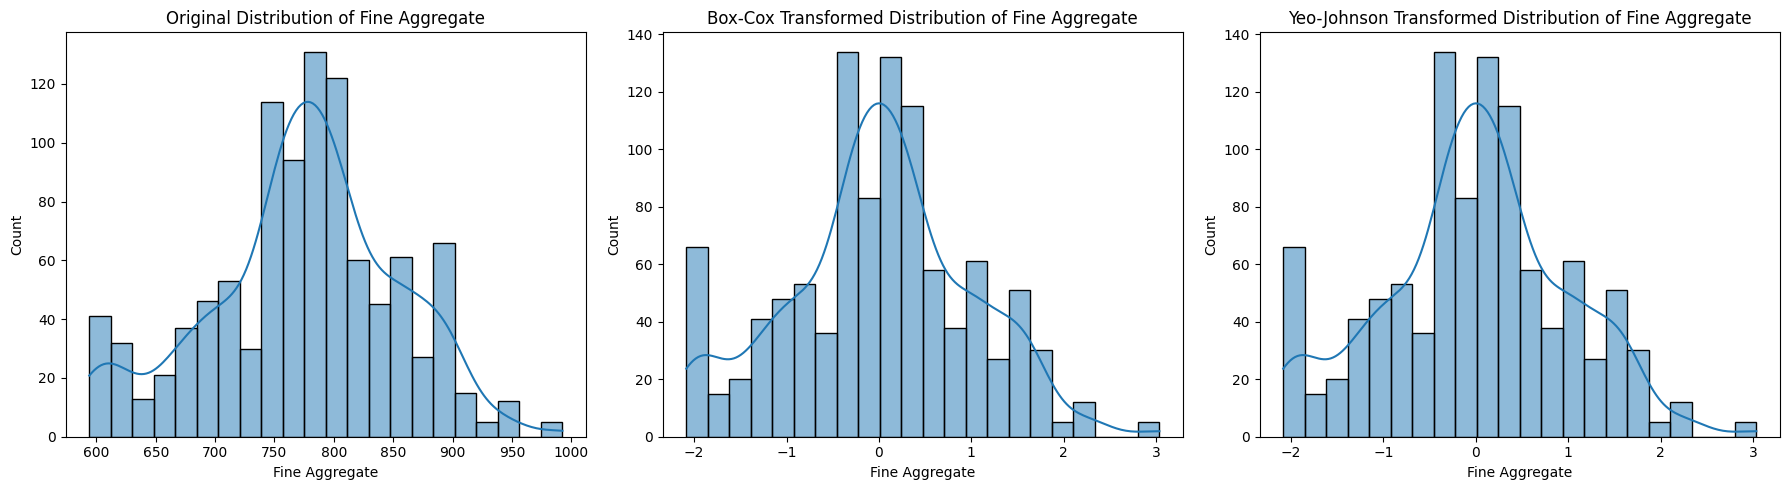

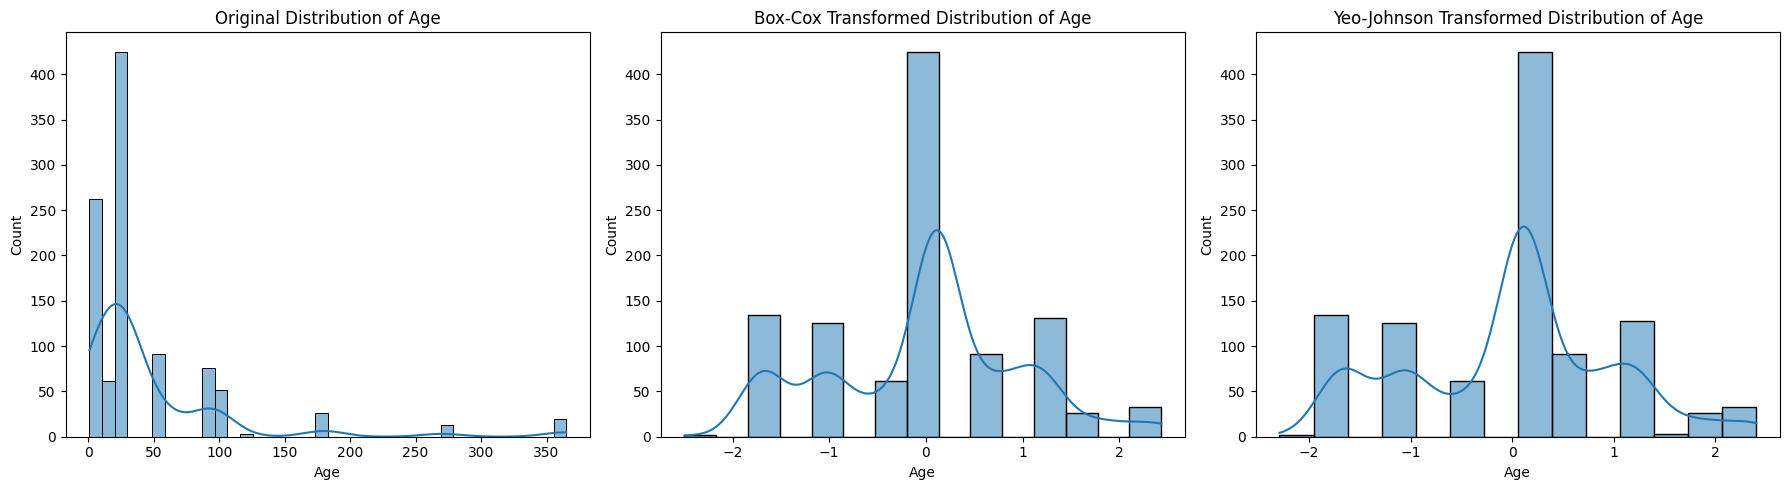

In [ ]:
for col in X.columns:
    plt.figure(figsize=(18, 5))

    # Plot original distribution
    plt.subplot(1, 3, 1)
    sns.histplot(X[col], kde=True)
    plt.title(f'Original Distribution of {col}')

    # Plot Box-Cox transformed distribution
    plt.subplot(1, 3, 2)
    sns.histplot(X_boxcox_transformed_df[col], kde=True)
    plt.title(f'Box-Cox Transformed Distribution of {col}')

    # Plot Yeo-Johnson transformed distribution
    plt.subplot(1, 3, 3)
    sns.histplot(X_yeojohnson_transformed_df[col], kde=True)
    plt.title(f'Yeo-Johnson Transformed Distribution of {col}')

    plt.tight_layout()
    plt.show()